<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/Taller_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 10 Puntos Un investigador desea comparar el tiempo de reacción de tres grupos de personas
sometidas a diferentes estímulos visuales. Se registraron los siguientes tiempos (en milisegundos):
Grupo 1 (n1 = 10): 250, 260, 245, 255, 248, 252, 258, 261, 249, 257.
Grupo 2 (n2 = 10): 265, 270, 260, 275, 268, 267, 272, 269, 271, 266.
Grupo 3 (n3 = 10): 240, 235, 242, 238, 236, 239, 241, 237, 243, 240.

Realice la prueba ANOVA de una vía con α = 0,05 para determinar si existen diferencias significa-
tivas en los tiempos medios de reacción entre los tres grupos.

DATOS ORIGINALES:
      Grupo  Tiempo_reaccion
0   Grupo 1              250
1   Grupo 1              260
2   Grupo 1              245
3   Grupo 1              255
4   Grupo 1              248
5   Grupo 1              252
6   Grupo 1              258
7   Grupo 1              261
8   Grupo 1              249
9   Grupo 1              257
10  Grupo 2              265
11  Grupo 2              270
12  Grupo 2              260
13  Grupo 2              275
14  Grupo 2              268
15  Grupo 2              267
16  Grupo 2              272
17  Grupo 2              269
18  Grupo 2              271
19  Grupo 2              266
20  Grupo 3              240
21  Grupo 3              235
22  Grupo 3              242
23  Grupo 3              238
24  Grupo 3              236
25  Grupo 3              239
26  Grupo 3              241
27  Grupo 3              237
28  Grupo 3              243
29  Grupo 3              240

Medias por Grupo:
  Grupo 1: 253.5000
  Grupo 2: 268.3000
  Grupo 3: 239.1000
Medi

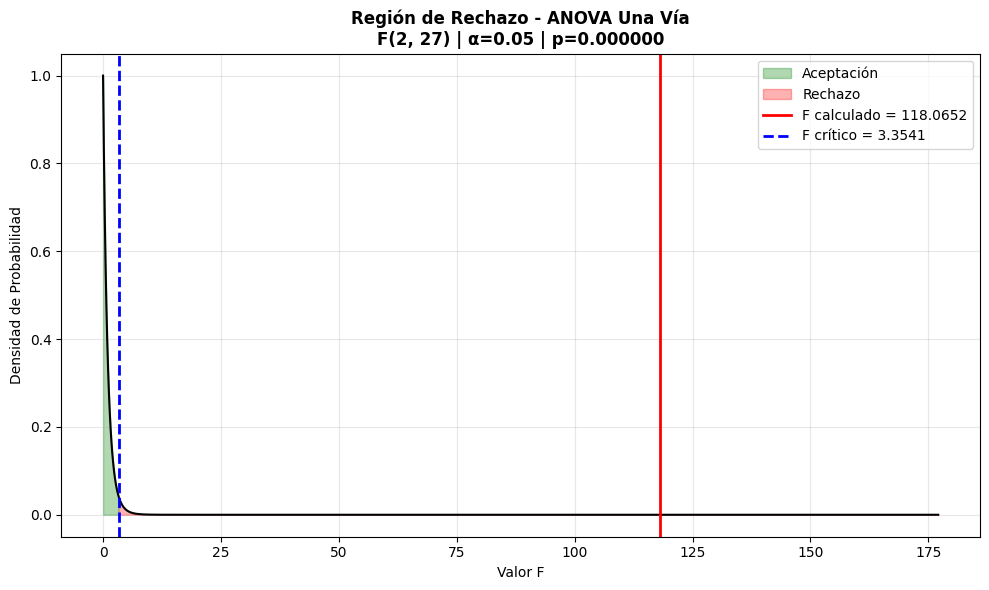

ANÁLISIS COMPLETO FINALIZADO


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ============================================================================
# DATOS DEL PROBLEMA
# ============================================================================

data = {
    'Grupo': ['Grupo 1'] * 10 + ['Grupo 2'] * 10 + ['Grupo 3'] * 10,
    'Tiempo_reaccion': [
        250, 260, 245, 255, 248, 252, 258, 261, 249, 257,
        265, 270, 260, 275, 268, 267, 272, 269, 271, 266,
        240, 235, 242, 238, 236, 239, 241, 237, 243, 240
    ]
}

df = pd.DataFrame(data)
grupos = df['Grupo'].unique()

# ============================================================================
# CÁLCULOS PRELIMINARES
# ============================================================================

datos = [df[df['Grupo'] == i]['Tiempo_reaccion'].values for i in grupos]
n_grupos = len(grupos)
n_obs = [len(g) for g in datos]
n_total = sum(n_obs)

media_global = df['Tiempo_reaccion'].mean()
medias_grupo = df.groupby('Grupo')['Tiempo_reaccion'].mean().values

print("DATOS ORIGINALES:")
print(df)
print("\nMedias por Grupo:")
for i, grupo in enumerate(grupos):
    print(f"  {grupo}: {medias_grupo[i]:.4f}")
print(f"Media Global: {media_global:.4f}\n")

# ============================================================================
# ANOVA DE UNA VÍA MANUAL
# ============================================================================

SCT = np.sum((df['Tiempo_reaccion'] - media_global)**2)
SCB = sum([n_obs[i]*(medias_grupo[i] - media_global)**2 for i in range(n_grupos)])
SCE = SCT - SCB

gl_b = n_grupos - 1
gl_e = n_total - n_grupos
gl_t = n_total - 1

CMb = SCB / gl_b
CMe = SCE / gl_e

F = CMb / CMe
p_value = 1 - stats.f.cdf(F, gl_b, gl_e)
F_crit = stats.f.ppf(0.95, gl_b, gl_e)

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("TABLA ANOVA DE UNA VÍA")
print("="*80)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12}")
print("-"*80)
print(f"{'Entre Grupos':<20} {SCB:>12.4f} {gl_b:>6} {CMb:>12.4f} {F:>12.4f} {p_value:>12.6f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_e:>6} {CMe:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_t:>6}")
print("="*80)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

alpha = 0.05
print(f"\nINTERPRETACIÓN ANOVA (α = {alpha}):")
print(f"  F calculado = {F:.4f}")
print(f"  F crítico = {F_crit:.4f}")
print(f"  Valor-p = {p_value:.6f}")

if p_value < alpha:
    print("  ✓ Hay diferencias significativas entre los tiempos medios de reacción por grupo.\n")
else:
    print("  ✗ No hay diferencias significativas entre los tiempos medios de reacción por grupo.\n")

# ============================================================================
# ANÁLISIS POST-HOC DE TUKEY (HSD)
# ============================================================================

if p_value < alpha:
    print("ANÁLISIS POST-HOC DE TUKEY (HSD):")
    tukey_result = pairwise_tukeyhsd(endog=df['Tiempo_reaccion'], groups=df['Grupo'], alpha=alpha)
    print(tukey_result)
    print("\nINTERPRETACIÓN TUKEY:")
    print("  Las columnas 'reject' indican si la hipótesis nula (no diferencia entre las medias) se rechaza.")
    print("  'True' significa que hay una diferencia significativa entre los pares de grupos.\n")
else:
    print("No se requiere un análisis Post-Hoc de Tukey, ya que el ANOVA no encontró diferencias significativas.")

# ============================================================================
# GRÁFICO DE REGIÓN DE RECHAZO
# ============================================================================

x = np.linspace(0, max(F, F_crit)*1.5, 1000)
y = stats.f.pdf(x, gl_b, gl_e)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=1.5)
plt.fill_between(x[x <= F_crit], y[x <= F_crit], color='green', alpha=0.3, label='Aceptación')
plt.fill_between(x[x >= F_crit], y[x >= F_crit], color='red', alpha=0.3, label='Rechazo')
plt.axvline(F, color='red', linewidth=2, label=f'F calculado = {F:.4f}')
plt.axvline(F_crit, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit:.4f}')
plt.title(f'Región de Rechazo - ANOVA Una Vía\nF({gl_b}, {gl_e}) | α={alpha} | p={p_value:.6f}', fontsize=12, fontweight='bold')
plt.xlabel('Valor F')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)